<a href="https://colab.research.google.com/github/ibrahim4606/Seasonal_Agriculture_Performance_Analysis_Ibrahim/blob/main/Seasonal_Agriculture_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🌾 Seasonal Agriculture Performance Analysis

### Major Project – VOIS AICTE

**Dataset:** `seasonal_agriculture_performance_dataset.csv`


In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

file_path = "/content/seasonal_agriculture_performance_dataset.csv"

data = pd.read_csv(file_path)

print(f"Dataset loaded successfully: {data.shape[0]:,} rows and {data.shape[1]} columns.")
display(data.head())


Dataset loaded successfully: 4,000 rows and 28 columns.


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30



## 1. Understanding the Dataset

Before asking analytical questions, I want to know what one row represents, which variables are available, and whether the dataset has any obvious quality issues.


In [ ]:

print("Number of rows:", len(data))
print("Number of columns:", data.shape[1])
print("\nColumn names:")
print(data.columns.tolist())

print("\nData types:")
display(data.dtypes.to_frame("Data Type"))

print("\nDuplicate rows:", data.duplicated().sum())


Number of rows: 4000
Number of columns: 28

Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data types:


,Data Type
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64



Duplicate rows: 0



## 2. Data Cleaning and Preparation

I will check missing values and duplicates first. I will not remove rows just because a value is missing; instead, numeric missing values will be filled with the median and categorical missing values with the mode.

This keeps the analysis usable while avoiding unnecessary loss of records.


In [ ]:

# Missing-value check
missing = data.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing):
    print("Columns with missing values:")
    display(missing.to_frame("Missing Values"))
else:
    print("No missing values found.")

print("Duplicate rows:", data.duplicated().sum())

# Make a working copy and clean it
df = data.copy()

numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

for col in numeric_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print("\nAfter cleaning:")
print("Remaining missing values:", int(df.isna().sum().sum()))
print("Remaining duplicate rows:", int(df.duplicated().sum()))


Columns with missing values:


,Missing Values
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


Duplicate rows: 0

After cleaning:
Remaining missing values: 0
Remaining duplicate rows: 0


## Q1. How does agricultural performance vary across seasons?

,Farms,Avg_Yield_Tonnes_Ha,Avg_Production_Tonnes,Avg_Profit_INR,Avg_Water_Efficiency
Season,,,,,
Kharif,1779,5.63,46.31,"178,914.65",5.89
Rabi,1627,5.04,41.49,"87,689.47",5.19
Zaid,594,4.64,38.89,"-24,804.82",4.41


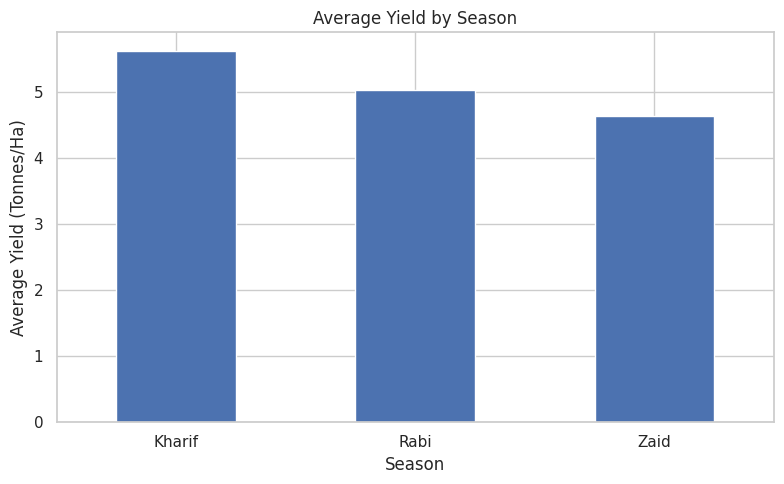

Human takeaway: Kharif has the highest average yield (5.63 tonnes/ha), while Zaid has the lowest (4.64 tonnes/ha).


In [ ]:

season_perf = df.groupby("Season").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
    Avg_Production_Tonnes=("Production_Tonnes", "mean"),
    Avg_Profit_INR=("Profit_INR", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).sort_values("Avg_Yield_Tonnes_Ha", ascending=False)

display(season_perf.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
season_perf["Avg_Yield_Tonnes_Ha"].plot(kind="bar", ax=ax)
ax.set_title("Average Yield by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

best_yield_season = season_perf["Avg_Yield_Tonnes_Ha"].idxmax()
lowest_yield_season = season_perf["Avg_Yield_Tonnes_Ha"].idxmin()
print(f"Human takeaway: {best_yield_season} has the highest average yield ({season_perf.loc[best_yield_season, 'Avg_Yield_Tonnes_Ha']:.2f} tonnes/ha), while {lowest_yield_season} has the lowest ({season_perf.loc[lowest_yield_season, 'Avg_Yield_Tonnes_Ha']:.2f} tonnes/ha).")


## Q2. What major seasonal patterns can we observe?

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct,Yield_Tonnes_Ha,Profit_INR,Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15,5.63,"178,914.65",54.47
Rabi,437.62,23.49,57.89,7.59,24.07,5.04,"87,689.47",40.48
Zaid,304.65,31.04,52.01,8.18,19.28,4.64,"-24,804.82",38.22


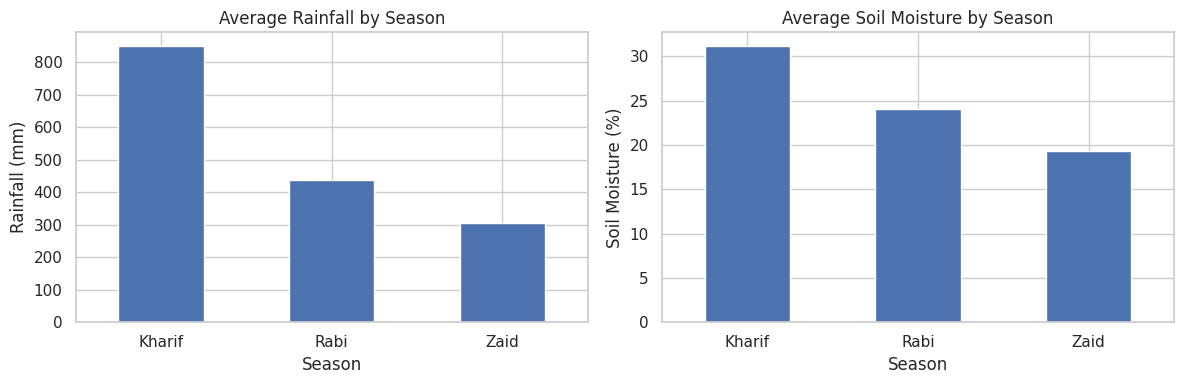

Human takeaway:
- Kharif: rainfall 849.2 mm, soil moisture 31.1%, yield 5.63 tonnes/ha.
- Rabi: rainfall 437.6 mm, soil moisture 24.1%, yield 5.04 tonnes/ha.
- Zaid: rainfall 304.6 mm, soil moisture 19.3%, yield 4.64 tonnes/ha.


In [ ]:

season_pattern = df.groupby("Season")[[
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
    "Sunlight_Hours_Day", "Soil_Moisture_pct",
    "Yield_Tonnes_Ha", "Profit_INR", "Disease_Pest_Risk_pct"
]].mean().round(2)

display(season_pattern)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
season_pattern["Rainfall_mm"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Average Rainfall by Season")
axes[0].set_ylabel("Rainfall (mm)")
axes[0].tick_params(axis="x", rotation=0)

season_pattern["Soil_Moisture_pct"].plot(kind="bar", ax=axes[1])
axes[1].set_title("Average Soil Moisture by Season")
axes[1].set_ylabel("Soil Moisture (%)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print("Human takeaway:")
for season in season_pattern.index:
    print(f"- {season}: rainfall {season_pattern.loc[season, 'Rainfall_mm']:.1f} mm, soil moisture {season_pattern.loc[season, 'Soil_Moisture_pct']:.1f}%, yield {season_pattern.loc[season, 'Yield_Tonnes_Ha']:.2f} tonnes/ha.")


## Q3. Which characteristics change between seasons?

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Disease_Pest_Risk_pct
Season,,,,,,,,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15,120.02,58.10,105.30,187.08,5.08,"6,102.20",54.47
Rabi,437.62,23.49,57.89,7.59,24.07,120.40,57.31,103.93,185.41,5.02,"5,846.99",40.48
Zaid,304.65,31.04,52.01,8.18,19.28,120.53,58.13,105.42,184.64,5.17,"6,419.89",38.22


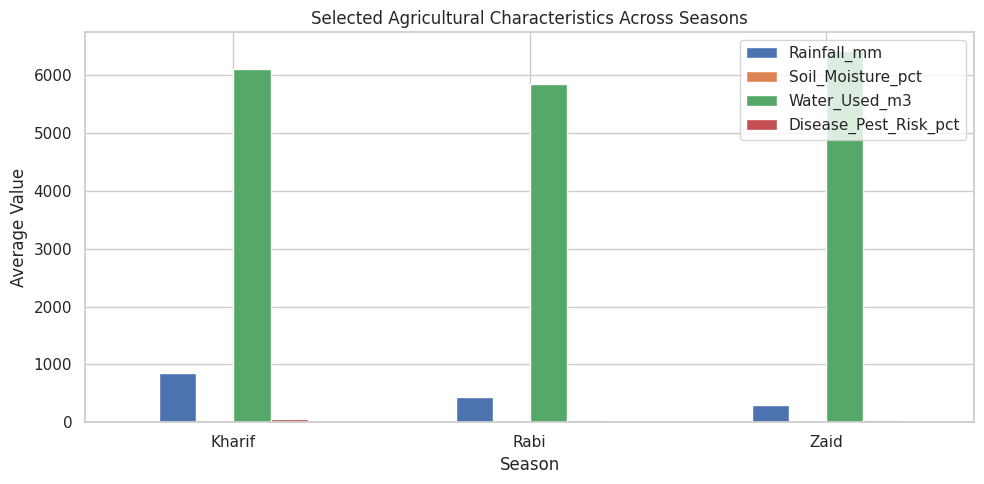

Human takeaway: the seasons are not identical. Environmental conditions, water use and risk levels change, so comparing agricultural performance without considering season could hide important differences.


In [ ]:

characteristics = df.groupby("Season")[[
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
    "Sunlight_Hours_Day", "Soil_Moisture_pct",
    "Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha",
    "Fertilizer_kg_ha", "Pesticide_Litre_ha",
    "Water_Used_m3", "Disease_Pest_Risk_pct"
]].mean().round(2)

display(characteristics)

# Show relative differences for selected variables
selected = ["Rainfall_mm", "Soil_Moisture_pct", "Water_Used_m3", "Disease_Pest_Risk_pct"]
fig, ax = plt.subplots(figsize=(10, 5))
characteristics[selected].plot(kind="bar", ax=ax)
ax.set_title("Selected Agricultural Characteristics Across Seasons")
ax.set_ylabel("Average Value")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print("Human takeaway: the seasons are not identical. Environmental conditions, water use and risk levels change, so comparing agricultural performance without considering season could hide important differences.")


## Q4. How do farming activities and irrigation practices differ across seasons?

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.80,33.20,26.00,18.00
Rabi,22.70,32.30,26.90,18.00
Zaid,23.60,32.70,23.60,20.20


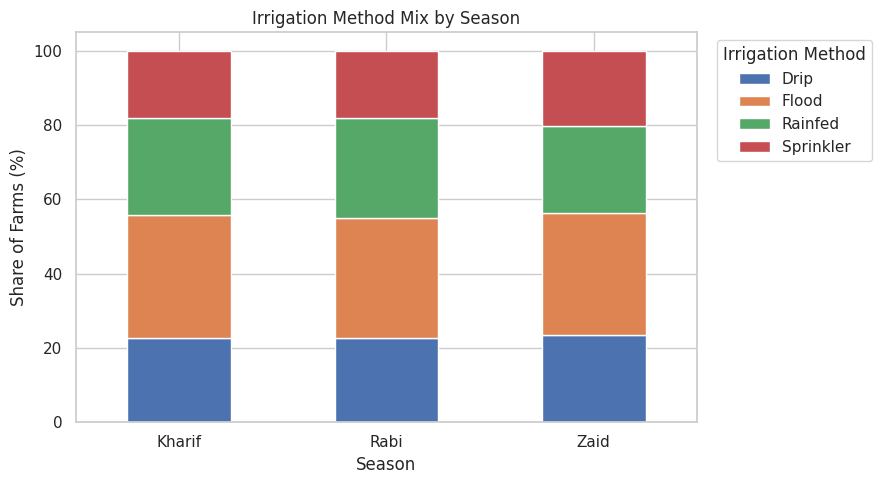

Human takeaway: In Kharif, the most common irrigation method is Flood (33.2% of farms).
Human takeaway: In Rabi, the most common irrigation method is Flood (32.3% of farms).
Human takeaway: In Zaid, the most common irrigation method is Flood (32.7% of farms).


In [ ]:

irrigation_by_season = pd.crosstab(df["Season"], df["Irrigation_Method"], normalize="index") * 100
display(irrigation_by_season.round(1))

fig, ax = plt.subplots(figsize=(9, 5))
irrigation_by_season.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Irrigation Method Mix by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Share of Farms (%)")
ax.legend(title="Irrigation Method", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

top_method = irrigation_by_season.idxmax(axis=1)
for season in irrigation_by_season.index:
    print(f"Human takeaway: In {season}, the most common irrigation method is {top_method[season]} ({irrigation_by_season.loc[season, top_method[season]]:.1f}% of farms).")


## Q5. Are resource usage levels different across seasons?

,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,
Kharif,187.08,5.08,"6,102.20",5.89
Rabi,185.41,5.02,"5,846.99",5.19
Zaid,184.64,5.17,"6,419.89",4.41


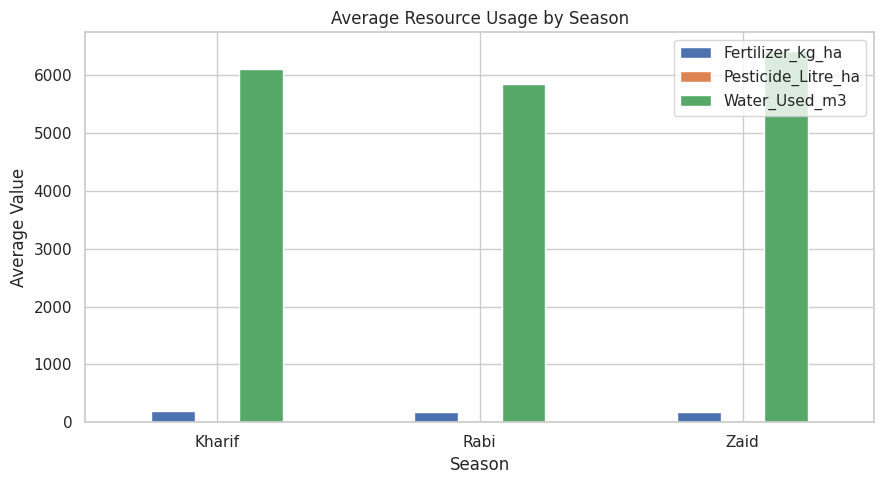

Human takeaway:
- Kharif: fertilizer 187.1 kg/ha, pesticide 5.08 L/ha, water 6102 m³.
- Rabi: fertilizer 185.4 kg/ha, pesticide 5.02 L/ha, water 5847 m³.
- Zaid: fertilizer 184.6 kg/ha, pesticide 5.17 L/ha, water 6420 m³.


In [ ]:

resources = df.groupby("Season")[[
    "Fertilizer_kg_ha", "Pesticide_Litre_ha", "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3"
]].mean().round(2)

display(resources)

fig, ax = plt.subplots(figsize=(9, 5))
resources[["Fertilizer_kg_ha", "Pesticide_Litre_ha", "Water_Used_m3"]].plot(kind="bar", ax=ax)
ax.set_title("Average Resource Usage by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Average Value")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print("Human takeaway:")
for season in resources.index:
    print(f"- {season}: fertilizer {resources.loc[season, 'Fertilizer_kg_ha']:.1f} kg/ha, pesticide {resources.loc[season, 'Pesticide_Litre_ha']:.2f} L/ha, water {resources.loc[season, 'Water_Used_m3']:.0f} m³.")


## Q6. Are environmental conditions related to agricultural performance?

,Correlation with Yield
Soil_pH,-0.02
Sunlight_Hours_Day,-0.02
Pesticide_Litre_ha,-0.01
Seed_Quality_Score,-0.01
Fertilizer_kg_ha,0.00
Potassium_kg_ha,0.00
Avg_Temperature_C,0.01
Soil_Moisture_pct,0.01
Humidity_pct,0.01
Disease_Pest_Risk_pct,0.01


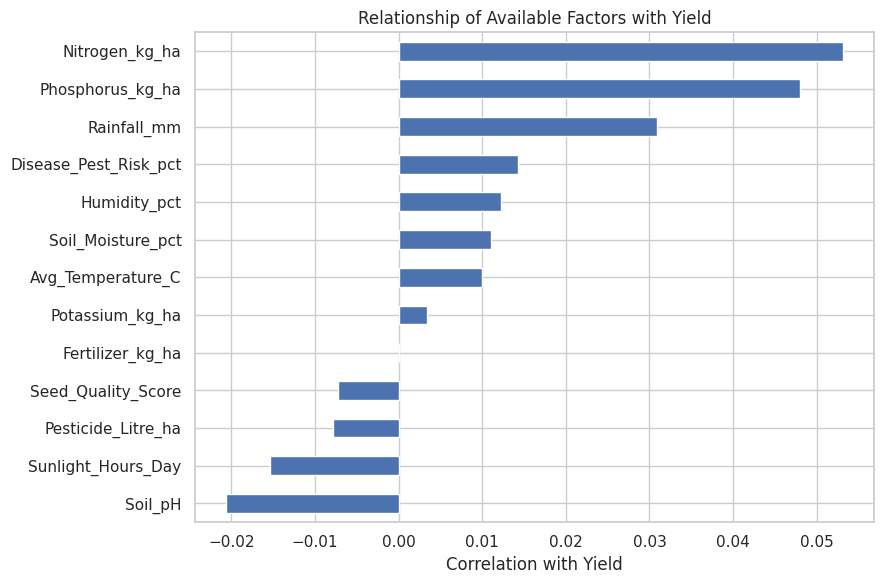

Human takeaway: the strongest observed relationships with yield in this dataset are:
- Nitrogen_kg_ha: correlation = 0.053
- Phosphorus_kg_ha: correlation = 0.048
- Rainfall_mm: correlation = 0.031

Important note: correlation shows association, not causation. It should not be interpreted as proof that one variable directly causes higher yield.


In [ ]:

factors = [
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
    "Sunlight_Hours_Day", "Soil_pH", "Soil_Moisture_pct",
    "Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha",
    "Fertilizer_kg_ha", "Pesticide_Litre_ha",
    "Seed_Quality_Score", "Disease_Pest_Risk_pct"
]

corr = df[factors + ["Yield_Tonnes_Ha"]].corr()["Yield_Tonnes_Ha"].drop("Yield_Tonnes_Ha").sort_values()

display(corr.to_frame("Correlation with Yield"))

fig, ax = plt.subplots(figsize=(9, 6))
corr.plot(kind="barh", ax=ax)
ax.set_title("Relationship of Available Factors with Yield")
ax.set_xlabel("Correlation with Yield")
plt.tight_layout()
plt.show()

strongest = corr.abs().sort_values(ascending=False).head(3).index.tolist()
print("Human takeaway: the strongest observed relationships with yield in this dataset are:")
for c in strongest:
    print(f"- {c}: correlation = {corr[c]:.3f}")

print("\nImportant note: correlation shows association, not causation. It should not be interpreted as proof that one variable directly causes higher yield.")


## Q7. How do economic outcomes vary across seasons?

,Avg_Revenue_INR,Avg_Cost_INR,Avg_Profit_INR,Profitable_Farm_Share
Season,,,,
Kharif,"710,719.06","531,804.41","178,914.65",57.79
Rabi,"601,526.05","513,836.58","87,689.47",48.86
Zaid,"519,171.90","543,976.73","-24,804.82",35.52


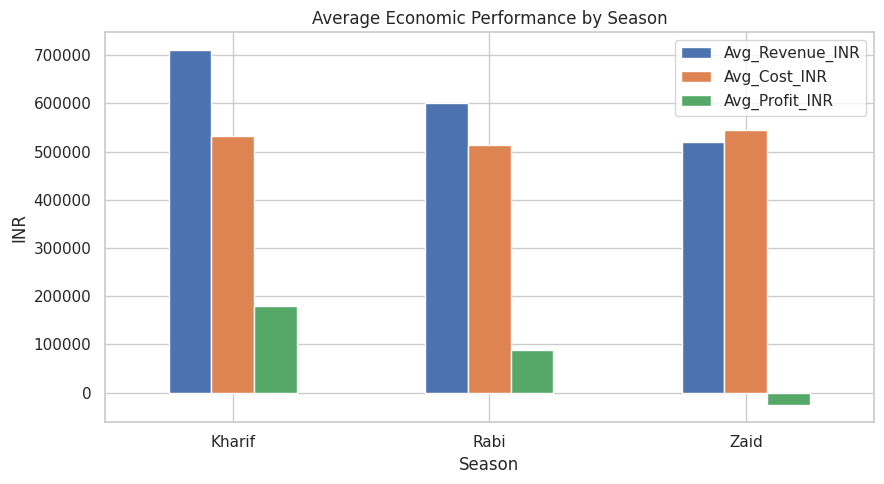

Human takeaway: Kharif has the highest average profit (178,915 INR), while Zaid has the lowest (-24,805 INR).
The profitable-farm percentage is also useful because an average profit alone can hide how widely the outcome is distributed.


In [ ]:

economics = df.groupby("Season").agg(
    Avg_Revenue_INR=("Revenue_INR", "mean"),
    Avg_Cost_INR=("Total_Cost_INR", "mean"),
    Avg_Profit_INR=("Profit_INR", "mean"),
    Profitable_Farm_Share=("Profit_INR", lambda x: (x > 0).mean() * 100)
).round(2)

display(economics)

fig, ax = plt.subplots(figsize=(9, 5))
economics[["Avg_Revenue_INR", "Avg_Cost_INR", "Avg_Profit_INR"]].plot(kind="bar", ax=ax)
ax.set_title("Average Economic Performance by Season")
ax.set_xlabel("Season")
ax.set_ylabel("INR")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

best_profit = economics["Avg_Profit_INR"].idxmax()
worst_profit = economics["Avg_Profit_INR"].idxmin()
print(f"Human takeaway: {best_profit} has the highest average profit ({economics.loc[best_profit, 'Avg_Profit_INR']:,.0f} INR), while {worst_profit} has the lowest ({economics.loc[worst_profit, 'Avg_Profit_INR']:,.0f} INR).")
print("The profitable-farm percentage is also useful because an average profit alone can hide how widely the outcome is distributed.")


## Q8. Which crops and regions perform better, and are the patterns consistent?

Crop-level performance:


,Farms,Avg_Yield,Avg_Profit,Avg_Water_Efficiency,Avg_Risk
Crop,,,,,
Sugarcane,305,46.64,"817,187.99",30.48,45.40
Maize,551,2.71,"-83,978.33",5.60,45.54
Rice,690,2.43,"-102,213.50",1.95,46.50
Wheat,614,2.11,"-123,398.34",4.63,47.85
Chilli,412,1.54,"750,878.34",2.95,46.06
Groundnut,424,1.32,"44,858.12",3.15,46.29
Cotton,508,1.23,"124,546.92",1.94,45.97
Pulses,496,0.92,"-4,238.05",2.90,46.57


State-level performance:


,Farms,Avg_Yield,Avg_Profit,Avg_Water_Efficiency
State,,,,
Punjab,484,6.12,"136,025.64",5.62
Maharashtra,512,5.02,"135,428.86",5.28
Karnataka,489,5.69,"119,422.34",5.56
Tamil Nadu,485,4.88,"117,744.75",5.31
Gujarat,488,5.66,"117,568.24",5.58
Telangana,516,5.04,"108,829.62",5.46
Madhya Pradesh,497,4.99,"86,840.76",5.27
Andhra Pradesh,529,4.63,"73,453.53",5.03


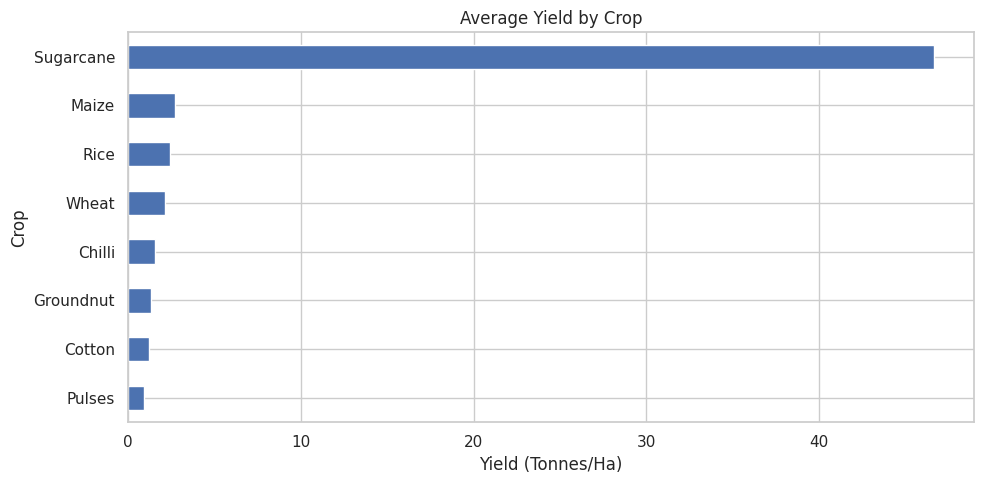

Human takeaway: Sugarcane has the highest average yield in this dataset, while Pulses has the lowest.
At the state level, Punjab has the highest average profit and Andhra Pradesh has the lowest average profit.
These comparisons are descriptive; crop mix and local conditions should be considered before calling one region universally better.


In [ ]:

crop_perf = df.groupby("Crop").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Risk=("Disease_Pest_Risk_pct", "mean")
).sort_values("Avg_Yield", ascending=False)

state_perf = df.groupby("State").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).sort_values("Avg_Profit", ascending=False)

print("Crop-level performance:")
display(crop_perf.round(2))

print("State-level performance:")
display(state_perf.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
crop_perf["Avg_Yield"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("Average Yield by Crop")
ax.set_xlabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

print(f"Human takeaway: {crop_perf.index[0]} has the highest average yield in this dataset, while {crop_perf.index[-1]} has the lowest.")
print(f"At the state level, {state_perf.index[0]} has the highest average profit and {state_perf.index[-1]} has the lowest average profit.")
print("These comparisons are descriptive; crop mix and local conditions should be considered before calling one region universally better.")


## Q9. Are there unusual or unexpected observations?

In [ ]:

# Use the IQR rule to flag unusually high/low yield observations.
q1 = df["Yield_Tonnes_Ha"].quantile(0.25)
q3 = df["Yield_Tonnes_Ha"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

yield_outliers = df[(df["Yield_Tonnes_Ha"] < lower) | (df["Yield_Tonnes_Ha"] > upper)]

print(f"Yield IQR lower bound: {lower:.2f}")
print(f"Yield IQR upper bound: {upper:.2f}")
print(f"Potential yield outliers: {len(yield_outliers):,} ({len(yield_outliers)/len(df)*100:.1f}% of rows)")

display(yield_outliers[[
    "Farm_ID", "State", "District", "Crop", "Season",
    "Yield_Tonnes_Ha", "Production_Tonnes", "Profit_INR",
    "Water_Used_m3", "Disease_Pest_Risk_pct"
]].sort_values("Yield_Tonnes_Ha", ascending=False).head(10))

print("\nHuman takeaway: these rows are not automatically errors. They are observations that are far from the typical yield range and may represent different crops, farm conditions or data-quality cases worth checking.")


Yield IQR lower bound: -1.62
Yield IQR upper bound: 5.50
Potential yield outliers: 302 (7.5% of rows)


,Farm_ID,State,District,Crop,Season,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Used_m3,Disease_Pest_Risk_pct
1715,SF11716,Gujarat,Indore,Sugarcane,Kharif,101.44,641.10,1608291,11781,60.10
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,95.79,"1,424.40",3330582,23289,42.70
3525,SF13526,Andhra Pradesh,Erode,Sugarcane,Rabi,93.13,648.18,1471529,10705,59.90
1464,SF11465,Gujarat,Nashik,Sugarcane,Kharif,91.98,703.65,2216708,12787,44.50
3523,SF13524,Karnataka,Nashik,Sugarcane,Kharif,91.46,75.00,234320,1944,54.40
2782,SF12783,Gujarat,Nalgonda,Sugarcane,Rabi,91.32,522.35,1236801,12199,50.60
644,SF10645,Andhra Pradesh,Ludhiana,Sugarcane,Kharif,89.34,668.26,1984818,11547,36.90
2847,SF12848,Telangana,Warangal,Sugarcane,Kharif,87.76,672.24,2041678,12526,67.80
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,84.75,"1,249.21",3378879,23936,43.80
1178,SF11179,Karnataka,Nalgonda,Sugarcane,Kharif,83.79,534.58,1200815,11086,54.20



Human takeaway: these rows are not automatically errors. They are observations that are far from the typical yield range and may represent different crops, farm conditions or data-quality cases worth checking.


## Q10. What are the strongest relationships visible in the data?

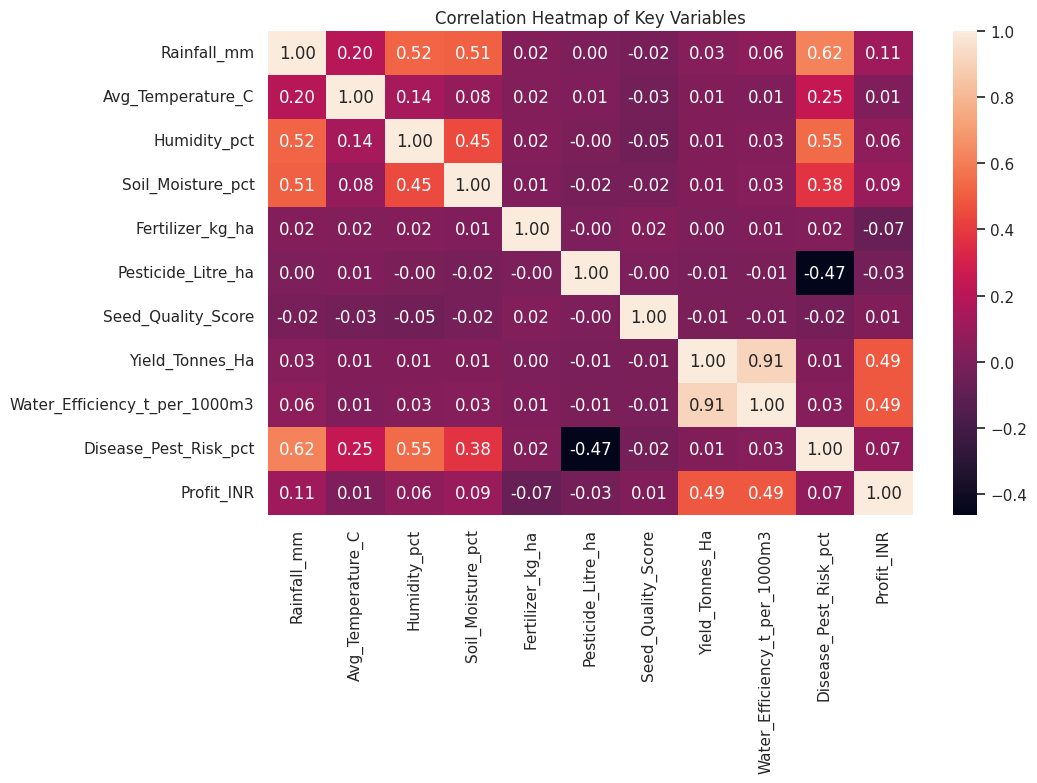

Strongest relationships (by absolute correlation):


,Variable_1,Variable_2,Correlation,Abs_Correlation
49,Yield_Tonnes_Ha,Water_Efficiency_t_per_1000m3,0.91,0.91
8,Rainfall_mm,Disease_Pest_Risk_pct,0.62,0.62
25,Humidity_pct,Disease_Pest_Risk_pct,0.55,0.55
1,Rainfall_mm,Humidity_pct,0.52,0.52
2,Rainfall_mm,Soil_Moisture_pct,0.51,0.51
53,Water_Efficiency_t_per_1000m3,Profit_INR,0.49,0.49
51,Yield_Tonnes_Ha,Profit_INR,0.49,0.49
43,Pesticide_Litre_ha,Disease_Pest_Risk_pct,-0.47,0.47
19,Humidity_pct,Soil_Moisture_pct,0.45,0.45
32,Soil_Moisture_pct,Disease_Pest_Risk_pct,0.38,0.38


Human takeaway: the heatmap helps identify where the variables move together. These are useful leads for deeper analysis, but they are not evidence of causation.


In [ ]:

relationship_cols = [
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
    "Soil_Moisture_pct", "Fertilizer_kg_ha", "Pesticide_Litre_ha",
    "Seed_Quality_Score", "Yield_Tonnes_Ha",
    "Water_Efficiency_t_per_1000m3", "Disease_Pest_Risk_pct",
    "Profit_INR"
]

relationship_corr = df[relationship_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(relationship_corr, annot=True, fmt=".2f", ax=ax)
ax.set_title("Correlation Heatmap of Key Variables")
plt.tight_layout()
plt.show()

# Show the strongest non-duplicate pair relationships
pairs = []
cols = relationship_corr.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        pairs.append((cols[i], cols[j], relationship_corr.iloc[i, j]))
pairs = pd.DataFrame(pairs, columns=["Variable_1", "Variable_2", "Correlation"])
pairs["Abs_Correlation"] = pairs["Correlation"].abs()

print("Strongest relationships (by absolute correlation):")
display(pairs.sort_values("Abs_Correlation", ascending=False).head(10))

print("Human takeaway: the heatmap helps identify where the variables move together. These are useful leads for deeper analysis, but they are not evidence of causation.")


## Q11. What conclusions can reasonably be drawn from the available data?

In [ ]:

# Build a compact evidence table for the final conclusion.
summary = pd.DataFrame({
    "Measure": [
        "Highest average yield season",
        "Lowest average yield season",
        "Highest average profit season",
        "Lowest average profit season",
        "Highest average yield crop",
        "Highest average profit state",
        "Most common irrigation method overall"
    ],
    "Finding": [
        df.groupby("Season")["Yield_Tonnes_Ha"].mean().idxmax(),
        df.groupby("Season")["Yield_Tonnes_Ha"].mean().idxmin(),
        df.groupby("Season")["Profit_INR"].mean().idxmax(),
        df.groupby("Season")["Profit_INR"].mean().idxmin(),
        df.groupby("Crop")["Yield_Tonnes_Ha"].mean().idxmax(),
        df.groupby("State")["Profit_INR"].mean().idxmax(),
        df["Irrigation_Method"].value_counts().idxmax()
    ]
})
display(summary)

print("Final humanized conclusion:")
print("1. Seasonal conditions are associated with clear differences in yield and profitability.")
print("2. Resource use and environmental measurements also vary across seasons.")
print("3. Crop and regional performance is not uniform, so local context matters.")
print("4. Irrigation method shows noticeable differences in yield and water-related measures.")
print("5. Some observations are unusual and should be reviewed instead of being removed automatically.")
print("6. The dataset supports evidence-based planning, but the analysis is observational and should not be treated as proof of cause-and-effect.")


,Measure,Finding
0,Highest average yield season,Kharif
1,Lowest average yield season,Zaid
2,Highest average profit season,Kharif
3,Lowest average profit season,Zaid
4,Highest average yield crop,Sugarcane
5,Highest average profit state,Punjab
6,Most common irrigation method overall,Flood


Final humanized conclusion:
1. Seasonal conditions are associated with clear differences in yield and profitability.
2. Resource use and environmental measurements also vary across seasons.
3. Crop and regional performance is not uniform, so local context matters.
4. Irrigation method shows noticeable differences in yield and water-related measures.
5. Some observations are unusual and should be reviewed instead of being removed automatically.
6. The dataset supports evidence-based planning, but the analysis is observational and should not be treated as proof of cause-and-effect.


## Q12. How can these findings support better seasonal agricultural planning?

In [ ]:

# Create recommendation-supporting comparisons.
irrigation = df.groupby("Irrigation_Method").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Water=("Water_Used_m3", "mean"),
    Avg_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Profit=("Profit_INR", "mean")
).sort_values("Avg_Profit", ascending=False)

display(irrigation.round(2))

print("Recommended actions based on the observed data:")
print("• Plan crops and farm activities with seasonal conditions in mind rather than using one strategy for every season.")
print("• Give extra attention to seasons with lower average yield or weaker profitability.")
print("• Compare irrigation choices using both yield and water efficiency, not only water volume.")
print("• Use crop- and region-level performance as a starting point for targeted planning.")
print("• Investigate high-risk or unusual observations before making operational decisions.")
print("• Track rainfall, soil moisture and other environmental indicators together with yield.")
print("• Review costs and market prices alongside production because higher production does not automatically mean higher profit.")


,Farms,Avg_Yield,Avg_Water,Avg_Efficiency,Avg_Profit
Irrigation_Method,,,,,
Drip,915,6.58,"5,918.75",6.27,"219,626.00"
Sprinkler,734,5.16,"6,208.26",4.67,"91,121.08"
Rainfed,1041,4.60,"3,549.55",7.56,"79,050.37"
Flood,1310,4.86,"8,026.47",3.44,"73,354.02"


Recommended actions based on the observed data:
• Plan crops and farm activities with seasonal conditions in mind rather than using one strategy for every season.
• Give extra attention to seasons with lower average yield or weaker profitability.
• Compare irrigation choices using both yield and water efficiency, not only water volume.
• Use crop- and region-level performance as a starting point for targeted planning.
• Investigate high-risk or unusual observations before making operational decisions.
• Track rainfall, soil moisture and other environmental indicators together with yield.
• Review costs and market prices alongside production because higher production does not automatically mean higher profit.
